       Raw Wins Raw Wins (%) Runs Better than BC (signif.)  \
Metric                                                       
Bias         53        66.25                             0   
MADp         64         80.0                            50   
MADc         58         72.5                            39   

       Runs Worse than BC (signif.) Runs Not Significant Percent Better (%)  \
Metric                                                                        
Bias                              1                   79                0.0   
MADp                              5                   25               62.5   
MADc                              6                   35              48.75   

       Percent Worse (%) Percent Not Significant (%) Mean Diff Median Diff  \
Metric                                                                       
Bias                1.25                       98.75 -0.008625      -0.008   
MADp                6.25                       31.25 -0.011

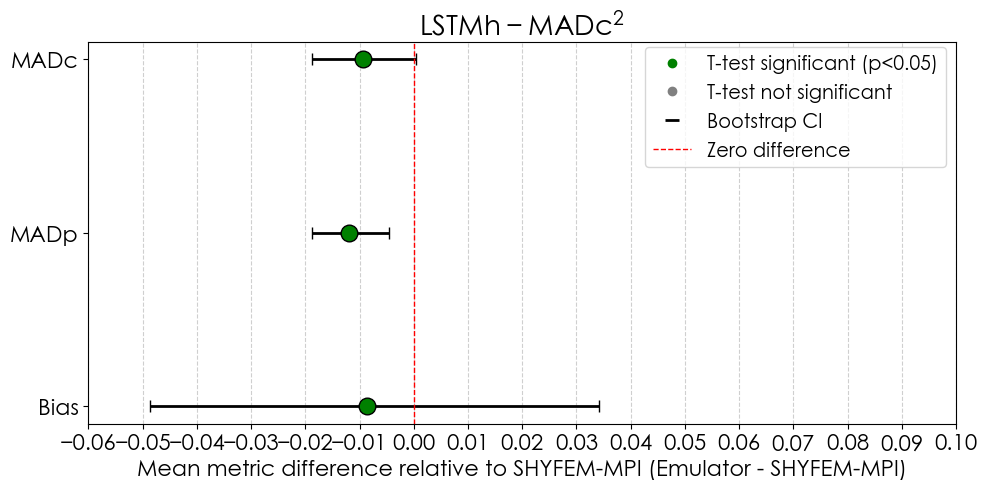

In [37]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# === Paths for both locations ===
#ml_method = 'MLR-MSE'
#ml_method = 'LSTMh-MSE'
#file_trieste = "Trieste/LSTMh-MSE/Bootstrap_with_RawMetrics_2026.txt"
#file_venezia = "VeneziaPS/LSTMh-MSE/Bootstrap_with_RawMetrics_2026.txt"

ml_method = r'$\mathrm{LSTMh-MADc}^2$'
#ml_method = r'$\mathrm{MLP-MADc}^2$'
#ml_method = r'$\mathrm{LSTMh-MADc}^2$'
file_trieste = "Trieste/LSTMh-MADc/Bootstrap_with_RawMetrics_2026.txt"
file_venezia = "VeneziaPS/LSTMh-MADc/Bootstrap_with_RawMetrics_2026.txt"

# === L#oad bootstrap results ===
df_trieste = pd.read_csv(file_trieste, sep="\t")
df_venezia = pd.read_csv(file_venezia, sep="\t")

# === Combine data for both locations ===
df_combined = pd.concat([df_trieste, df_venezia], axis=0).reset_index(drop=True)

# === Metrics to aggregate ===
#metrics = ["MAD", "Bias", "MADp", "MADc"]
metrics = ["Bias", "MADp", "MADc"]
summary = {}

for metric in metrics:
    diff_col = f"Diff_{metric}"
    ci_low_col = f"CI_{metric}_low"
    ci_high_col = f"CI_{metric}_high"
    
    # Raw wins
    if metric == "Bias":
        raw_wins = (df_combined[f"Bias_em"].abs() < df_combined[f"Bias_bc"].abs()).sum()
    else:
        raw_wins = (df_combined[f"{metric}_em"] < df_combined[f"{metric}_bc"]).sum()
    
    # Corrected bootstrap categories
    better = (df_combined[diff_col] < 0) & (df_combined[ci_high_col] < 0)
    worse = (df_combined[diff_col] > 0) & (df_combined[ci_low_col] > 0)
    similar = ~(better | worse)
    
    # Paired t-test
    # ---------------------------------------
    # Bias uses ABSOLUTE bias magnitude
    # ---------------------------------------
    if metric == "Bias":
    
        diffs = (
            np.abs(df_combined["Bias_em"].values)
            - np.abs(df_combined["Bias_bc"].values)
        )
    
        if np.std(diffs) < 1e-10:
            t_stat, p_val = np.nan, 0.0
            t_test_note = "All runs identical (t-test not applicable)"
        else:
            t_stat, p_val = ttest_rel(
                np.abs(df_combined["Bias_em"].values),
                np.abs(df_combined["Bias_bc"].values)
            )
            t_test_note = ""
    
    else:
    
        diffs = (
            df_combined[f"{metric}_em"].values
            - df_combined[f"{metric}_bc"].values
        )
    
        if np.std(diffs) < 1e-10:
            t_stat, p_val = np.nan, 0.0
            t_test_note = "All runs identical (t-test not applicable)"
        else:
            t_stat, p_val = ttest_rel(
                df_combined[f"{metric}_em"].values,
                df_combined[f"{metric}_bc"].values
            )
            t_test_note = ""
    
    summary[metric] = {
        "Raw Wins": raw_wins,
        "Raw Wins (%)": raw_wins / len(df_combined) * 100,
        "Runs Better than BC (signif.)": better.sum(),
        "Runs Worse than BC (signif.)": worse.sum(),
        "Runs Not Significant": similar.sum(),
        "Percent Better (%)": better.sum() / len(df_combined) * 100,
        "Percent Worse (%)": worse.sum() / len(df_combined) * 100,
        "Percent Not Significant (%)": similar.sum() / len(df_combined) * 100,
        "Mean Diff": df_combined[diff_col].mean(),
        "Median Diff": df_combined[diff_col].median(),
        "t-statistic": t_stat,
        "t-test p-value": p_val,
        "t-test note": t_test_note
    }

df_summary = pd.DataFrame(summary).T
df_summary.index.name = "Metric"
print(df_summary)

# === Plotting (T-test only, with bootstrap CIs) ===
y_pos = np.arange(len(metrics))

# T-test
x_t = df_summary["Mean Diff"]
pvals_t = df_summary["t-test p-value"]
colors_t = ["green" if p < 0.05 else "gray" for p in pvals_t]
y_t = y_pos  # now use the main y position (no offset)

# Bootstrap CIs (still used for error bars, but centered on t-test results)
ci_low_b, ci_high_b = [], []
for m in metrics:
    diff_mean = df_combined[f"Diff_{m}"].mean()
    ci_low = df_combined[f"CI_{m}_low"].mean()
    ci_high = df_combined[f"CI_{m}_high"].mean()
    
    ci_low_b.append(diff_mean - ci_low)
    ci_high_b.append(ci_high - diff_mean)

plt.rcParams['font.family'] = 'Century Gothic'  # Replace with your preferred font
plt.rcParams['mathtext.default'] = 'rm'
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Century Gothic'

fig, ax = plt.subplots(figsize=(10, 5))

# T-test markers + CIs
for xi, yi, err_low, err_high, color in zip(x_t, y_t, ci_low_b, ci_high_b, colors_t):
    ax.errorbar(xi, yi, xerr=[[err_low], [err_high]], fmt='o', 
                color='black', markerfacecolor=color, markersize=12, 
                ecolor='black', elinewidth=2, capsize=4)

# Reference line
ax.axvline(0, color="red", linestyle="--", linewidth=1)

# Axis formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(metrics)
ax.set_xlabel("Mean metric difference relative to SHYFEM-MPI (Emulator - SHYFEM-MPI)", fontsize=16)
ax.set_title(f'{ml_method}', fontsize=20)
ax.grid(axis='x', linestyle='--', alpha=0.6)
plt.tick_params(axis='both', labelsize=16)
ax.set_xlim(-0.06, 0.05)
ax.set_xticks(np.arange(-0.06, 0.11, 0.01))

# Legend
green_dot = Line2D([], [], color='green', marker='o', linestyle='None', markersize=6, label='T-test significant (p<0.05)')
gray_dot = Line2D([], [], color='gray', marker='o', linestyle='None', markersize=6, label='T-test not significant')
bootstrap_ci = Line2D([], [], color='black', marker='_', markersize=10, markeredgewidth=2, linestyle='None', label='Bootstrap CI')
vline_red = Line2D([], [], color='red', linestyle='--', linewidth=1, label='Zero difference')

ax.legend(handles=[green_dot, gray_dot, bootstrap_ci, vline_red],
          loc='center left', bbox_to_anchor=(0.63, 0.83),
          borderaxespad=0.5, frameon=True, fontsize=14)

plt.tight_layout()
#plt.savefig("Tt_only_with_CI_MLR-MADc.png", dpi=300, bbox_inches='tight')
plt.savefig("Tt_only_with_CI_LSTMh-MADc.png", dpi=300, bbox_inches='tight')
#plt.show()
